# Ft. Huachucah Methods
This is a review of the methods used to calculate biomass in the Ft. Huachucah area.

## Field Collection Methods



In [1]:
# import calc_biomass package
import sys
sys.path.append('../')
from calc_biomass import manage_data

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Jupyter magic to make plots display interactive
# must install ipympl (Ipython-matplotlib) and nodejs
from ipywidgets.embed import embed_minimal_html
%matplotlib widget

## Canopy Biomass Calculation Methods
### Calculating DRC from DBH
If a tree had a central stem, regardless of species, diameter was measured at DBH. But if the tree had multiple stems from a common root base, DRC (diameter at root collar was measured). Which measurement was used was recorded in the dataset. Most allometric equations require either DBH or DRC, so to be consistent within a species, the following equation was applied to the Excel spreadsheet to convert DBH to DRC for oak, pinyon, and juniper species.

    Chojnacky, D. 1988. Juniper, Pinyon, Oak, and Mesquite Volume Equations for Arizona. USDA Forest Service, Intermountain Research Station, Research Paper INT-RP-391. Ogden, UT.

### Calculating Equivalent DRC

Using standard protocol for Diameter at Root Collar (DRC), when multiple stems joined to a single root collar below the soil, individual stems were measured for the same tree. These multiple basal measurements must be combined into a single measurement using the equation:

equivalent diameter = $\sqrt{\sum_{i=1}^{n}}RCD_{i}^{2}$

This equation is provided in both of:
    
    Chojnakcy, D.C. 1992 . Estimating volume and biomass for dryland oak speices. In: Ffolliott P.F., Gottfried, G.J., Bennett, D.A., Hernandez, C.V.-M., Ortega-Rubio, A., and R.H. Hamre, technical coordinators. Ecology and management of oak and associated woodlands: perspectives in the southwestern United States and Northern Mexico. Proceedings April 7-30, 1992; Sierra Vista, AZ. USDA Forest Service, Rocky Mountain Forest and Range Experiment Station General Technical Report RM-218:155-161.
    
    Grier, C.C., Elliott, K.J., McCullough, D.G. 1992. Biomass distribution and productivity of Pinus edulis-Juniperus monosperma woodlands of north-central Arizona. Forest Ecology and Management, 50:331-350.

In [2]:
def calc_edrc(df):
    # df is one tree id from a single plot
    # for trees with only one tree id, the sqrt(d2) == d
    dbh = (sum(df['dbh']**2))**0.5
    
    other_val = df.max()

    newdf = pd.DataFrame()
    newdf.loc[1,'DBH'] = dbh
    newdf.loc[1, df.columns] = other_val

    return newdf

In [3]:
# load data
data = manage_data.LoadData()
data.load_data(data.data_path)

# calculate ERC
data.df.rename(columns={'Final DBH/DRC':'dbh', 'spp':'Species','Species Code':'spp'}, inplace=True)
data.df = data.df.groupby(['Plot', 'Tree Number']).apply(calc_edrc).reset_index()

In [4]:
# Error noted below, now the new df with it's new index needs to have units reassigned, but the column names are all changed around
data.units['input']['DBH'] = data.units['input'].pop('Final DBH/DRC')
data.check_df_units('input')

### Cleaning the data
A number of quality assurance procedures applied in the other Ft. Huachuca Jupyter notebooks identified the following data cleaning requirements.

In [5]:
# clean data

# missing species for generic pinyon
pied = data.df.spp.isna() & (data.df.Species=='Pinyon')
data.df.loc[pied, 'spp'] = 'PIED'

# height for mesquite are in cm, not clinometer %
prve = (data.df['spp']=='PRVE')&(data.df['Height']<=0)
data.df.loc[prve, 'Height'] = data.df.loc[prve, 'Base reading']/100

# height for acacia are in cm, not m
segr = (data.df['spp']=='SEGR10')&(data.df['Height'].pint.magnitude>=100)
data.df.loc[segr, 'Height'] = data.df.loc[segr, 'Height']/100

# height for creosote are in cm, not m
latr = (data.df['spp']=='LATR2')&(data.df['Height'].pint.magnitude>=100)
data.df.loc[latr, 'Height'] = data.df.loc[latr, 'Height']/100

# accidentally flipped the sign of a juniper height clinometer %
jude = (data.df['spp']=='JUDE2')&(data.df['Height']<0)
ht = (-data.df.loc[jude, 'Top Reading']- data.df.loc[jude, 'Base reading']) / 100 * data.df.loc[jude, 'Distance (M)']
data.df.loc[jude, 'Height'] = ht

# quarter inch drc tree 2 cm circumference (actual circumference 200 cm)
qrt_in = (data.df['spp']=='QUEM')&(data.df['DBH'].pint.magnitude<1)
c = 200
d = c/np.pi
d_in = d/2.54
data.df.loc[qrt_in, 'DBH'] = d_in
data.df.loc[qrt_in, 'DBH/DRC Circumfrence (cm)'] = 200

# 3m DRC (circumference 94, not 944)
m3 = (data.df['spp']=='QUOB')&(data.df['DBH'].pint.magnitude>117)
c = 94
dbh_cm = c / np.pi
dbh_in = dbh_cm / 2.54
data.df.loc[m3, 'DBH'] = dbh_in
data.df.loc[m3, 'DBH/DRC Circumfrence (cm)'] = c

# cbh cleaning- if there is no clino reading, replace with nan. Mostly impacts dead trees
no_cbh = data.df['Lowest Canopy Height Reading'].isna()
data.df.loc[no_cbh, 'Lowest Canopy Height'] = np.nan

### Calculating biomass

Biomass is calculated in up to 3 categories:

* Total biomass- includes tree boles, foliage, and all branches
* Foliar biomass
* Available canopy fuel- this is defined as foliage + 0.5 * (0-6mm branches)

Available canopy fuel is defined in:

    Scott, J., Reinhardt, E. 2001. Assessing crown fire potential by linking models of surface and crown fire behavior. USDA, Forest Service, Rocky Mountain Research Station, Res. Pap. RMRS-RP-29

    Brown, J.K., Reinhardt, E. D. 1991. Predicting and managing fuel consumption in the interior west. In: Andrews, P., Potts, D., eds. Proceedings of the 11th conference on fire and forest meteorology. Proceedings April 16-19, 1991; Missoula, MT. Society of American Foresters. 

#### Allometric equations

##### Oaks
This equation uses a small branchwood size class of 0-50mm, which is larger than the 1 hour fuel class, which is 0-6mm. This will cause it to over-estimate available canopy fuel.

This equations derives foliage and small branchwood from total stem volume. In rare cases (1 in our dataset), if the equation is used with drc's below 7 cm and heights below 2 m it can produce negative volume. In these cases, the stemwood volume is then recalculated as the volume of cylinder.

    Chojnakcy, D.C. 1992 . Estimating volume and biomass for dryland oak speices. In: Ffolliott P.F., Gottfried, G.J., Bennett, D.A., Hernandez, C.V.-M., Ortega-Rubio, A., and R.H. Hamre, technical coordinators. Ecology and management of oak and associated woodlands: perspectives in the southwestern United States and Northern Mexico. Proceedings April 7-30, 1992; Sierra Vista, AZ. USDA Forest Service, Rocky Mountain Forest and Range Experiment Station General Technical Report RM-218:155-161.

##### Pinyon and Juniper
This equation uses a small branchwood size class of 0-25 mm, which is larger than the 1 hour fuel class, which is 0-6 mm.

    Grier, C.C., Elliott, K.J., McCullough, D.G. 1992. Biomass distribution and productivity of Pinus edulis-Juniperus monosperma woodlands of north-central Arizona. Forest Ecology and Management, 50:331-350.

1 hour fuels use branchwood adjustment factor from FuelCalc:

    Lutes, D. 2020. FuelCalc User's Guide (version 1.7). USDA Forest Service, Rocky Mountain Research Station.


##### Pines

Equations used require tree volume from the BC Ministry of Forestry volume tables.

In rare cases (1 in our dataset) where trees are dead with a broken top, leaving a short, thick cylinder, the volume equations underestimate the volume of the tree enough to unbalance the equation and produce negative biomass. In these cases, the volume is recalculated as a cylinder.

    Standish, J.T., Manning, G.H., and Demaerschalk, J.P. 1985. Development of biomass equations for British Columbia tree species. Canadian Forestry Service, Pacific Forest Research Centre, Information Report BC-X-264 (Vancouver, BC)

    Susan Watts eds. 1983. Forestry Handbook for British Columbia, 4th Edition. University of British Columbia. Forest Club.

##### Mesquite
This equation uses a small branchwood size class of 0-10mm, which is larger than the 1 hour fuel class, which is 0-6mm. This will cause it to over-estimate available canopy fuel.

    McClaran, M.P., McMurtry, C.R., Archer, S.R. 2013. A tool for estimating impacts of woody encroachment in arid grasslands: Allometric equations for biomass, carbon and nitrogen content in Posopis veluntina. Journal of Arid Environnments 88(2013): 39-12
    

In [6]:
wt = manage_data.CalcBiomass(data)
# what equations should be used for these species?
wt.add_equ_column()

In [7]:
wt.calc_biomass('total')

In [8]:
wt.calc_biomass('foliage')

In [9]:
wt.calc_biomass('avl_canfuel')

### Graphing the distribution by trees
A quick look at the distribution of biomasses per tree.

Text(0, 0.5, 'Biomass (kg)')

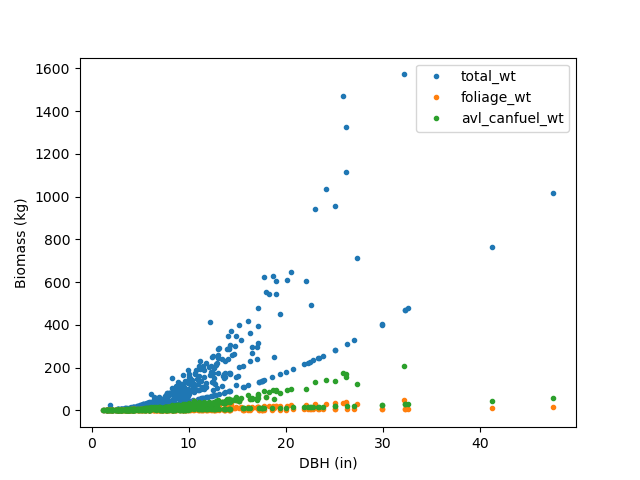

In [10]:
df = wt.ldata.df.pint.dequantify().droplevel(level=1, axis=1)
df = df[['DBH', 'Height','total_wt', 'foliage_wt', 'avl_canfuel_wt']].dropna()
plt.figure()
plt.plot(df['DBH'], df[['total_wt', 'foliage_wt', 'avl_canfuel_wt']], linestyle='', marker='.')

plt.legend(['total_wt', 'foliage_wt', 'avl_canfuel_wt'])
plt.xlabel('DBH (in)')
plt.ylabel('Biomass (kg)')

Text(0, 0.5, 'Biomass (kg)')

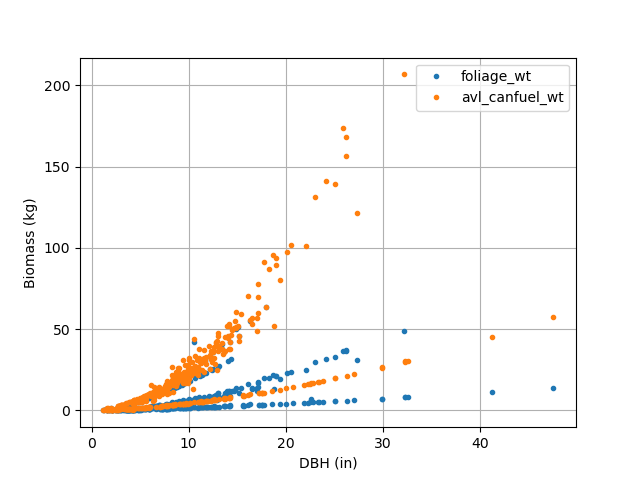

In [11]:
plt.figure()
plt.plot(df['DBH'], df[['foliage_wt', 'avl_canfuel_wt']], linestyle='', marker='.')

plt.legend(['foliage_wt', 'avl_canfuel_wt'])
plt.grid('on')
plt.xlabel('DBH (in)')
plt.ylabel('Biomass (kg)')

Text(0, 0.5, 'Biomass (kg)')

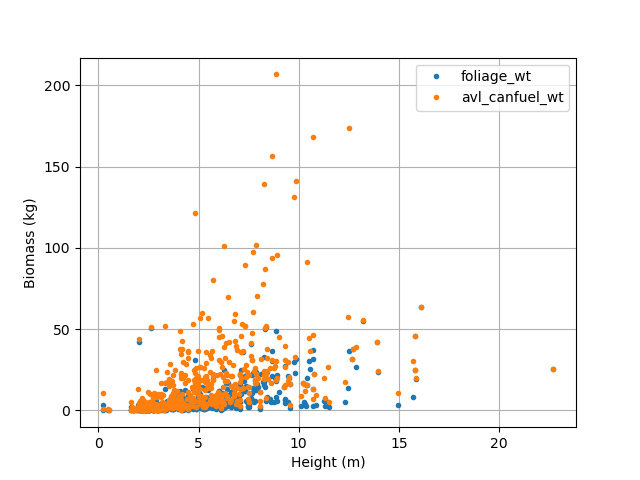

In [12]:
plt.figure()
plt.plot(df['Height'], df[['foliage_wt', 'avl_canfuel_wt']], linestyle='', marker='.')

plt.legend(['foliage_wt', 'avl_canfuel_wt'])
plt.grid('on')
plt.xlabel('Height (m)')
plt.ylabel('Biomass (kg)')

Text(0, 0.5, 'Height (m)')

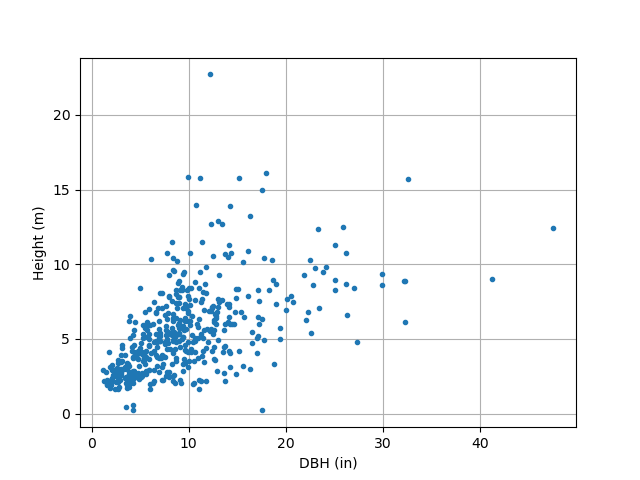

In [13]:
plt.figure()
plt.plot(df['DBH'], df['Height'], linestyle='', marker='.')

plt.grid('on')
plt.xlabel('DBH (in)')
plt.ylabel('Height (m)')

## Reducing biomass of dead trees
Dead trees should have some reduction in biomass. Talking over the field protocols with Zito, he made a clear distinction in the field between trees with foliage (red and dead or green; class 2) and trees with 0-15% of their foliage remaining (class 3). Put another way, many or most of the class 3 trees had no foliage left, but none of them had more than 15% remaining. So the decision is to remove all foliar biomass. We will leave the branchwood and bark, and assume that "candlestick" snags where all branches and bark have sloughed off are rare.

In [14]:
dead = wt.ldata.df['Tree Condition'] == 3

wt.ldata.df.loc[dead, 'total_wt'] -= wt.ldata.df.loc[dead, 'foliage_wt']
wt.ldata.df.loc[dead, 'avl_canfuel_wt'] -= wt.ldata.df.loc[dead, 'foliage_wt']
wt.ldata.df.loc[dead, 'foliage_wt'] = 0

## Summarizing by plot
For each plot, get the total amount of fuel, and summarize by plot size.

In [33]:
from pint import UnitRegistry
import pint_pandas

ureg = UnitRegistry()
pint_pandas.PintType.ureg = ureg

In [51]:
new_df = pd.DataFrame(index=wt.ldata.df['Plot'].unique())

fuel_col =  ['total_wt', 'avl_canfuel_wt', 'foliage_wt']
ht_col = ['Height', 'Lowest Canopy Height']
plt_size = np.pi * (10*ureg.m)**2

for plot, pdf in wt.ldata.df.groupby('Plot'):
    
    new_df.loc[plot, fuel_col] = pdf[fuel_col].sum() / plt_size
    new_df.loc[plot, ht_col] = pdf[ht_col].mean()
   
    mean_ba = ((np.pi*(pdf['DBH']/2)**2).mean())
    new_df.loc[plot, 'QMD'] = (2*(mean_ba/np.pi)**0.5).to('cm')

In [52]:
new_df

,total_wt,avl_canfuel_wt,foliage_wt,Height,Lowest Canopy Height,QMD
101,4.741179203015274 kilogram / meter ** 2,0.4806756497184368 kilogram / meter ** 2,0.32971007536731056 kilogram / meter ** 2,11.495625 meter,5.754125 meter,45.104484315147275 centimeter
105,10.946957782646848 kilogram / meter ** 2,1.1562118223116873 kilogram / meter ** 2,0.512496090314922 kilogram / meter ** 2,8.968181818181817 meter,5.080363636363636 meter,53.67113375748511 centimeter
167,4.383035203731403 kilogram / meter ** 2,0.7010096700201875 kilogram / meter ** 2,0.3116137118435915 kilogram / meter ** 2,6.079085714285715 meter,2.769442857142857 meter,29.358348399020826 centimeter
307,10.940636333567108 kilogram / meter ** 2,1.7383127063350488 kilogram / meter ** 2,0.829807153318786 kilogram / meter ** 2,7.134513333333334 meter,3.30154 meter,44.839418219296945 centimeter
308,1.7771777066770085 kilogram / meter ** 2,0.34116125094090094 kilogram / meter ** 2,0.29915397235562996 kilogram / meter ** 2,7.510183333333334 meter,3.71035 meter,31.81029174710643 centimeter
358,7.293706348308039 kilogram / meter ** 2,1.449937040734962 kilogram / meter ** 2,0.5991581438088911 kilogram / meter ** 2,4.715333333333334 meter,2.2546309523809525 meter,19.349648207077394 centimeter
411,2.228411244548217 kilogram / meter ** 2,0.3839687076164069 kilogram / meter ** 2,0.09588336490414252 kilogram / meter ** 2,5.039999999999999 meter,1.6200000000000003 meter,34.455166617851575 centimeter
462,5.256337880915642 kilogram / meter ** 2,0.7558184146857703 kilogram / meter ** 2,0.1915761968873845 kilogram / meter ** 2,6.42 meter,1.7399999999999998 meter,54.252306799280205 centimeter
513,3.5672028182081936 kilogram / meter ** 2,0.4805777501117079 kilogram / meter ** 2,0.244340724729013 kilogram / meter ** 2,6.654333333333333 meter,2.4300833333333336 meter,38.49189303798774 centimeter
553,1.3847059197993246 kilogram / meter ** 2,0.27738954094157336 kilogram / meter ** 2,0.0634542591730166 kilogram / meter ** 2,5.536499999999999 meter,1.146 meter,27.565219568539117 centimeter
